In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import combinations

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
dfEf = pd.read_csv('../Data/Figures_2-3-4/constructs_df.csv', index_col=0)
dfSim = pd.read_csv('../Data/Figures_2-3-4/constructs_df_sim.csv')

dfSim['construct'] = dfSim['construct'].str.replace('GOOSE_', '').astype(int)
df = pd.merge(dfEf, dfSim, on='construct')

In [3]:
def plot_ef_vs_ree(df, constructs, figsize=(3, 4),
                   top_ef=0.45, bot_ef=0.15,
                   top_ree=10, bot_ree=80,
                   ylabel_ef='$E_f$', ylabel_ree='$R_{ee}$ (Å)',
                   n_ree=3):
    plot_df = df[df['construct'].isin(constructs)].copy()
    plot_df['construct'] = pd.Categorical(plot_df['construct'],
                                          categories=constructs,
                                          ordered=True)
    plot_df = plot_df.sort_values('construct')

    fig, ax = plt.subplots(figsize=figsize)
    ax2 = ax.twinx()

    x_positions = np.arange(len(constructs))

    ef_x, ef_y = [], []
    ree_x, ree_y = [], []
    construct_data_list = []

    for idx, (x_pos, construct) in enumerate(zip(x_positions, constructs)):
        row = plot_df[plot_df['construct'] == construct].iloc[0]

        ef_x.append(x_pos)
        ef_y.append(row['Ef_cell'])
        ree_x.append(x_pos)
        ree_y.append(row['NaCl_0.1_SC_avg_Ree'])

        construct_data_list.append({
            'x_pos': x_pos,
            'ef_cell': row['Ef_cell'],
            'ef_cell_std': row['Ef_cell_std'],
            'n_wells': row['n_wells'],
            'ree': row['NaCl_0.1_SC_avg_Ree'],
            'ree_std': row['NaCl_0.1_SC_std_Ree'],
        })

        ax.errorbar(x_pos, row['Ef_cell'], yerr=row['Ef_cell_std'],
                    fmt='o', color='green', markersize=11, capsize=7,
                    linewidth=2, capthick=2, alpha=0.8, ecolor='grey',
                    label='$E_f$ (cell)' if idx == 0 else '')

        ax2.errorbar(x_pos, row['NaCl_0.1_SC_avg_Ree'],
                     yerr=row['NaCl_0.1_SC_std_Ree'],
                     fmt='s', color='blue', markersize=11, capsize=7,
                     linewidth=2, capthick=2, alpha=0.8, ecolor='grey',
                     label='$R_{ee}$ (SC)' if idx == 0 else '')

    ax.plot(ef_x, ef_y, color='grey', linestyle='-', linewidth=1.5, alpha=0.6, zorder=0)
    ax2.plot(ree_x, ree_y, color='grey', linestyle='-', linewidth=1.5, alpha=0.6, zorder=0)

    if len(constructs) == 2:
        data1 = construct_data_list[0]
        data2 = construct_data_list[1]

        def p_to_symbol(p):
            if p > 0.05:
                return 'ns'
            elif p > 0.01:
                return '*'
            elif p > 0.001:
                return '**'
            elif p > 0.0001:
                return '***'
            else:
                return '****'

        # Welch's t-test for Ef_cell
        _, p_value_cell = stats.ttest_ind_from_stats(
            data1['ef_cell'], data1['ef_cell_std'], data1['n_wells'],
            data2['ef_cell'], data2['ef_cell_std'], data2['n_wells'],
            equal_var=True)
        sig_symbol_cell = p_to_symbol(p_value_cell)

        # Welch's t-test for Ree
        _, p_value_ree = stats.ttest_ind_from_stats(
            data1['ree'], data1['ree_std'], n_ree,
            data2['ree'], data2['ree_std'], n_ree,
            equal_var=True)
        sig_symbol_ree = p_to_symbol(p_value_ree)

        x1 = data1['x_pos']
        x2 = data2['x_pos']
        mid_x = (x1 + x2) / 2

        # Ef_cell bracket (below, "u" shape, green) on ax
        offset_cell = 0.04
        y_bot1_cell = data1['ef_cell'] - data1['ef_cell_std']
        y_bot2_cell = data2['ef_cell'] - data2['ef_cell_std']
        y_min_cell = min(y_bot1_cell, y_bot2_cell)
        y_bracket_cell = y_min_cell - offset_cell
        y_leg1_cell = y_bracket_cell + (y_bot1_cell - y_bracket_cell) / 3
        y_leg2_cell = y_bracket_cell + (y_bot2_cell - y_bracket_cell) / 3
        ax.plot([x1, x1], [y_bracket_cell, y_leg1_cell], color='green', linewidth=1.5, alpha=0.8)
        ax.plot([x1, x2], [y_bracket_cell, y_bracket_cell], color='green', linewidth=1.5, alpha=0.8)
        ax.plot([x2, x2], [y_bracket_cell, y_leg2_cell], color='green', linewidth=1.5, alpha=0.8)
        ax.text(mid_x, y_bracket_cell - 0.01, sig_symbol_cell,
                fontsize=12, ha='center', va='top', color='green', fontweight='bold')

        # Ree bracket (above visually = smaller Ree on inverted axis, inverted "n" shape, blue) on ax2
        offset_ree = 5.0
        y_top1_ree = data1['ree'] - data1['ree_std']
        y_top2_ree = data2['ree'] - data2['ree_std']
        y_min_ree = min(y_top1_ree, y_top2_ree)
        y_bracket_ree = y_min_ree - offset_ree
        y_leg1_ree = y_bracket_ree + (y_top1_ree - y_bracket_ree) / 3
        y_leg2_ree = y_bracket_ree + (y_top2_ree - y_bracket_ree) / 3
        ax2.plot([x1, x1], [y_bracket_ree, y_leg1_ree], color='blue', linewidth=1.5, alpha=0.8)
        ax2.plot([x1, x2], [y_bracket_ree, y_bracket_ree], color='blue', linewidth=1.5, alpha=0.8)
        ax2.plot([x2, x2], [y_bracket_ree, y_leg2_ree], color='blue', linewidth=1.5, alpha=0.8)
        ax2.text(mid_x, y_bracket_ree, sig_symbol_ree,
                 fontsize=12, ha='center', va='bottom', color='blue', fontweight='bold')

    ax.set_xlim(-0.5, len(constructs) - 0.5)
    ax.set_ylim(bot_ef, top_ef)
    ax2.set_ylim(bot_ree, top_ree)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel(ylabel_ef, fontsize=14, color='green')
    ax2.set_ylabel(ylabel_ree, fontsize=14, color='blue')
    ax.tick_params(axis='y', colors='green')
    ax2.tick_params(axis='y', colors='blue')
    ax.grid(True, alpha=0.3, axis='y')

    y_range = top_ef - bot_ef
    for i, construct in enumerate(constructs):
        ax.text(i, bot_ef + y_range * 0.01,
                f'#{construct}', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    plt.tight_layout()
    return fig, ax

(<Figure size 300x400 with 2 Axes>, <Axes: ylabel='$E_f$'>)

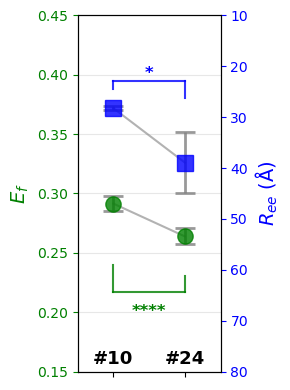

In [4]:
plot_ef_vs_ree(df, [10, 24])
#plt.savefig('/Users/trev/Downloads/Fig_Insilico-Ef_10-24.svg')

(<Figure size 300x400 with 2 Axes>, <Axes: ylabel='$E_f$'>)

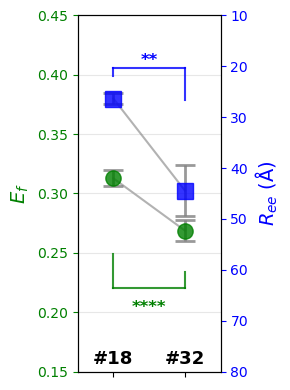

In [5]:
plot_ef_vs_ree(df, [18, 32])
#plt.savefig('/Users/trev/Downloads/Fig_Insilico-Ef_18-32.svg')

(<Figure size 300x400 with 2 Axes>, <Axes: ylabel='$E_f$'>)

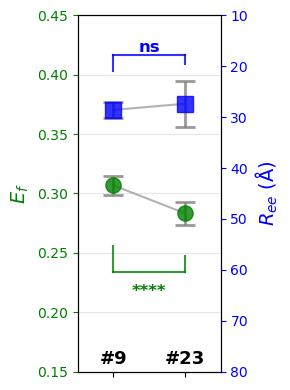

In [6]:
plot_ef_vs_ree(df, [9, 23])
#plt.savefig('/Users/trev/Downloads/Fig_Insilico-Ef_9-23.svg')

(<Figure size 300x400 with 2 Axes>, <Axes: ylabel='$E_f$'>)

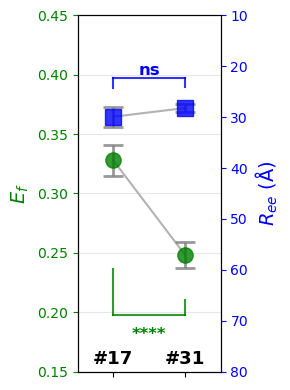

In [7]:
plot_ef_vs_ree(df, [17, 31])
#plt.savefig('/Users/trev/Downloads/Fig_Insilico-Ef_17-31.svg')